1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from scipy.stats import norm
from scipy.integrate import trapezoid

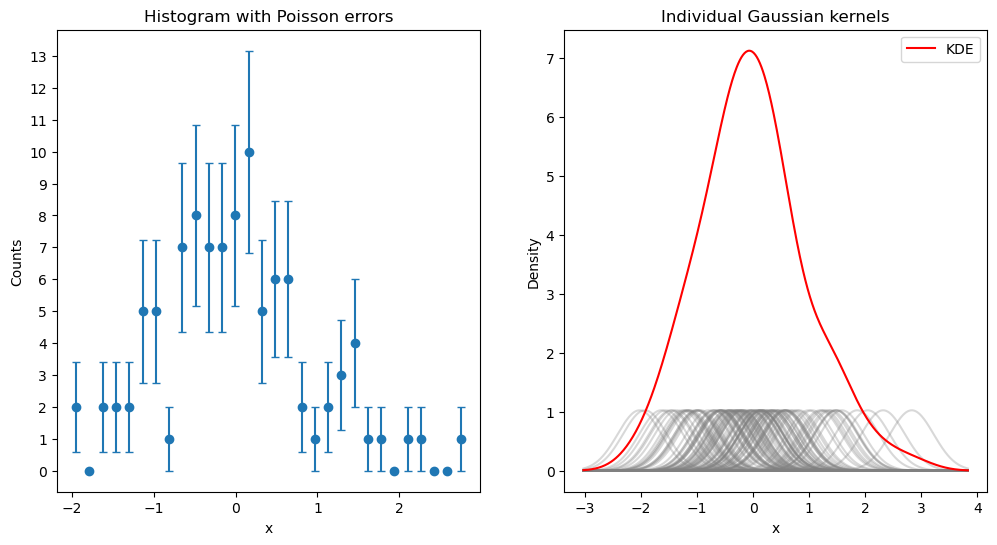

In [2]:
# Numpy array, x, of len(N) (with N=O(100)) with a variable normally distributed, with a given mean and standard deviation.
N = 100
mean = 0.0
std = 1.0
x = np.random.normal(loc=mean, scale=std, size=N)

# Histogram in pyplot taking properly care about the aesthetic.
bins = 30
counts, bin_edges = np.histogram(x, bins=bins) # " counts " is the number of counts in each bin and " bin_edges " an array with the limits of each bin.
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1]) # First one goes from 1 to end while second goes from 0 to one before the last.
errors = counts**0.5 # Poisson uncertainty.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.errorbar(bin_centers, counts, yerr=errors, fmt='o', capsize=3)

ax1.set_ylabel("Counts")
ax1.set_xlabel("x")
ax1.yaxis.set_major_locator(MultipleLocator(1)) # To have only integer labels.
ax1.set_title("Histogram with Poisson errors")

# Create a gaussian with the mean corresponding to the element value and std as a parameter that can be tuned.
sigma = 1.06 * x.std() * x.size ** (-1/5) # Bandwidth (std of each Gaussian).
xx = np.linspace(x.min() - 1, x.max() + 1, 500) # We extend limits because Gaussians have tails.
gaussians = np.array([norm.pdf(xx, loc=xi, scale=sigma) for xi in x]) # Each gaussian is evaluated in 500 points.

# In a separate plot, plot all the gaussian functions so obtained.
for g in gaussians:
    ax2.plot(xx, g, color='gray', alpha=0.3)
ax2.set_xlabel("x")
ax2.set_ylabel("Density")
ax2.set_title("Individual Gaussian kernels")

# (With np.sum()) all Gaussian functions summed and normalized so that the result is such that the integral coincides with the integral of the original histogram.
kde = np.sum(gaussians, axis=0)
hist_bin_width = bin_edges[1] - bin_edges[0]
hist_integral = np.sum(hist_bin_width * counts) # This is the sum of the area (base multiplied by height) of each bin (rectangle).
kde_integral = trapezoid(kde, xx)
kde *= hist_integral / kde_integral # Normalization so that the result is such that the integral coincides with the integral of the original histogram.
ax2.plot(xx, kde, color='red', label='KDE')
ax2.legend()
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


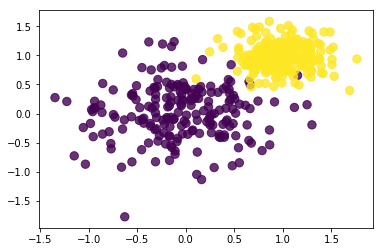

In [3]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot